In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  #3D plot



# LSN Exercises 08
## Variational Monte Carlo with simulated annealing

Gabriele Borroni (14768A)
---

## The variational principle

In quantum physics,the exact representation of the wavefunction typically requires resources that grow exponentially with the number of degrees of freedom, by making it rapidly impossible to compute it analytically. 

One of the most used approaches to tackle this complexity is the **variational principle**, which states that the **local energy** evaluated with any (good) chosen form of $\psi(x)$ will always be **greater than the actual ground state energy of the system**, which can be derived using the "true" $\psi_0(x)$:
$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

the idea is to choose a **parametric form** for the ansatz, and then optimize it using **the local energy as loss function**. 

In this exercise, the focus is on a 1D particle subjected to the potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

And the ansatz is chosen as:

$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$




To do this, two other tools are needed: an algorithm to sample from $\Psi_T^{\sigma,\mu}$ (without knowing its normalization constant) and an algorithm to choose the parameters that minimize the loss.

## The Metropolis algorithm

The Metropolis algorithm is a perfect tool for sampling from a PDF without knowing its normalization constant. As discussed in the previous exercise 6, this algorithm consists in a Markov chain process that, after an equilibration period, builds up a distribution of samples coincident with the target one.

For this case, the target distribution is the position's one $|\Psi_T^{\sigma,\mu}(x)|^2$. By starting at the current position $x_i$:

1. propose the next position as in a random walk (with random step length):
$$
x'=x_i+u \delta
$$

Where u is a uniform random number in [-1,1] and $\delta$ is the maximum amplitude of the step. A proper choice of $\delta$ is fundamental for maintaining a target acceptance around 51%.

2. Evaluate acceptance probability as:
$$
A(x_i\to x')=\min(1, \frac{\Psi_T^{\sigma,\mu}(x')}{\Psi_T^{\sigma,\mu}(x_i)})
$$

3. accept the move with probability A, and move to the new configuration if this happens. 

by repeating this algorithm, the generated sequence of samples will reproduce the one drawn from $|\Psi_T^{\sigma,\mu}(x)|^2$.

## The simulated annealing algorithm

Simulated annealing is an optimization algorithm inspired to the process of **crystals formation**, a way used by nature to find the minimum of the energy through **gradual cooling**.

The key idea is to interpret the loss function $L(x)$ as the energy of a statistical-mechanics system, and to associate a Boltzmann distribution:
$$
P(x)=\frac{e^{-\beta L(x)}}{Z}
$$
At high temperature (low $\beta$), the distribution is broad, allowing exploration of the configuration space; as the temperature decreases (high $\beta$), the probability becomes increasingly concentrated around the minima of L(x).

 The **simulated annealing protocol** consists in defining a cooling schedule
  $$
  (\beta_1, n_1),\dots,(\beta_N, n_N)
  $$ 

 This leads to introduce an **inner Metropolis algorithm** that will sample the new parameters of the trial wavefunction, according to the Boltzmann distribution of the loss (energy):
 1. Propose a new configuration of the variational parameters as:
 $$
 \begin{cases}
 \sigma'=\sigma_i+u*\delta \\
 \mu'=\mu_i+u'*\delta \\
 \end{cases}
 $$
 2. evaluate the difference of energy with the new parameters:
 $$
\Delta E= E(\sigma', \mu')-E(\sigma, mu)
 $$

 3. accept the move with probability:
 $$
 \begin{cases}
 1 & \text{if}    \Delta E<0 \\
 \min(1,e^{-\beta\Delta e}) & \text{else}
 \end{cases}
 $$

4. If the move has been accepted, move to the next configuration. Repeat.


 At each step i, $n_i$ Monte Carlo samplings are drawn at temperature $\beta_i$. 
 Initially, at high temperatures, the algorithm explores widely with fewer samples; later, at low temperatures, it refines the search around the minima, using more samples to improve accuracy. It's important to notice that the gradual cooling is realized by using the final configuration at each temperature $\beta_i$ as the initial one at temperature $\beta_{i+1}$.

 This algorithm has been implemented in the class VMC in VariationalMC.cpp to optimize the variational parameters of the trial wavefuncion.

 Due to the nature of this algorithm, it is expected that in the first phase of the optimization, the metropolis acceptance will be almost 100%, because at high temperature the exploration of the parameters landscape is favoured. Meanwhile, the acceptance is expected to drop down as the temperature lowers, and in the coolest phases it should be below 50%: the algorithm is now exploring a narrow region around the minimum, and only the best parameters can be chosen. 

 The plots for the acceptance during the optimization are shown below, it's clear that the algorithm meets the assumption made above. It is possible to see also the mean energy during optimization, and a comparison with the theoretical ground state energy of the system, obtain by exact quadrature.

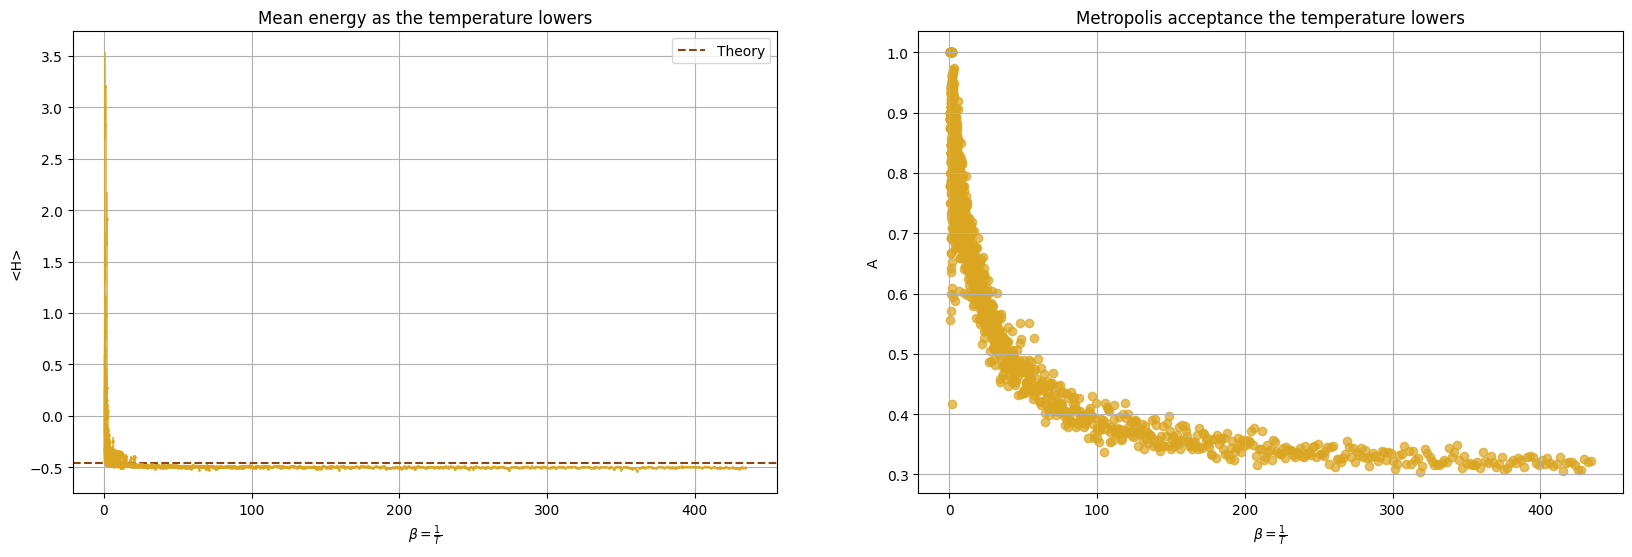

In [13]:
data=np.loadtxt("OUTPUT/energies_SA.dat")
accSa=np.loadtxt("OUTPUT/acceptance_sa.dat")
acc_sa=accSa[:,1]
beta=accSa[:,0]
Beta=data[:,0]
H=data[:,1]
err=data[:,2]
theory=-0.46046587969271513
fig, ax= plt.subplots(1,2, figsize=(20,6))
ax[0].errorbar(Beta,H, yerr=err, fmt='-o', ms=1.2, color="GoldenRod", alpha=0.7)
ax[0].grid(True)
ax[0].set_title("Mean energy as the temperature lowers")
ax[0].set_xlabel(r"$\beta=\frac{1}{T}$")
ax[0].set_ylabel("<H>")
ax[0].axhline(-0.46046587969271513, color='saddlebrown', label="Theory", ls='--')
ax[0].legend()
ax[1].scatter(beta, acc_sa, color='GoldenRod', alpha=0.7)
ax[1].grid(True)
ax[1].set_title("Metropolis acceptance the temperature lowers")
ax[1].set_xlabel(r"$\beta=\frac{1}{T}$")
ax[1].set_ylabel("A")
plt.show()

---
Below the plots of the sampled parameters during training show the convergence towards the best $(\sigma, \mu)$ configuration. From these plots, it's again evident that when the temperature is higher, the exploration of the parameters space is much stronger, which leads to broad sampled points.

As the temperature lowers, the sample of the new parameters becomes more concentrated in the optimal region of lowest energy configurations.

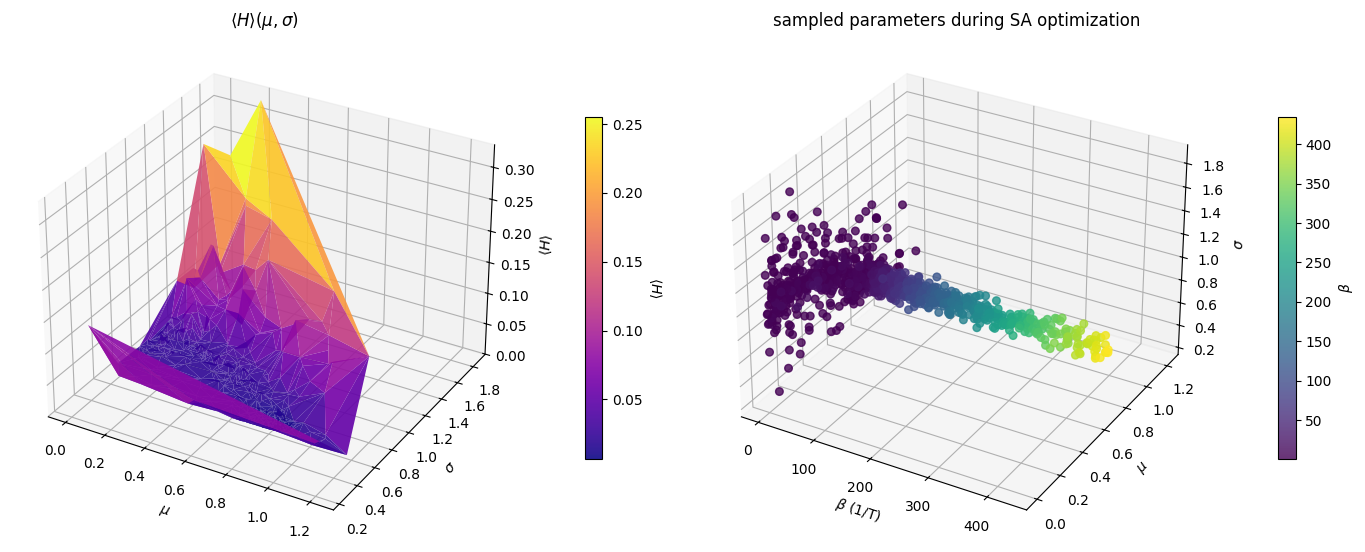

In [14]:

sigma = data[:, 3]
mu = data[:, 4]
H = data[:, 2] 
pars = np.loadtxt("OUTPUT/parameters_walk.dat")
sigma_walk = pars[:, 1]
mu_walk = pars[:, 2]
beta = pars[:, 0]
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_trisurf(mu, sigma, H, cmap='plasma', edgecolor='none', alpha=0.9)
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$\sigma$')
ax1.set_zlabel(r'$\langle H \rangle$')
ax1.set_title(r"$\langle H \rangle(\mu, \sigma)$")
cbar1 = fig.colorbar(surf, ax=ax1, shrink=0.6, pad=0.1)
cbar1.set_label(r"$\langle H \rangle$", rotation=270, labelpad=15)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc = ax2.scatter(beta, mu_walk, sigma_walk, c=beta, cmap='viridis', s=30, alpha=0.8)
ax2.set_xlabel(r"$\beta$ (1/T)")
ax2.set_ylabel(r"$\mu$")
ax2.set_zlabel(r"$\sigma$")
ax2.set_title("sampled parameters during SA optimization")
cbar2 = fig.colorbar(sc, ax=ax2, shrink=0.6, pad=0.1)
cbar2.set_label(r"$\beta$")
plt.tight_layout()
plt.show()


---

After the optimization, the best parameters found give out a good approximation for the atual wavefunction. From this one, mean energy and an histogram with the PDF $|\psi_{best}(x)|^2$ have been computed using data blocking, and then put in comparison with results obtained by translating Schroedinger's equation into matricial form. To do so, it is sufficient to discretize the space, and to evaluate $\psi(x)$ for each point on the grid. The wavefunction then becomes a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

Thus the time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form.

By evaluating second derivatives one gets:
$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation is sufficient to find eigenstates and eigenvalues of the matrix just obtained.

As it can be seen from the plots, there is a great match between the theoretical result and the VMC one. This conferms that this type of approach is a powerful tool to approximate wavefunctions when it's impossible to compute it analytically.

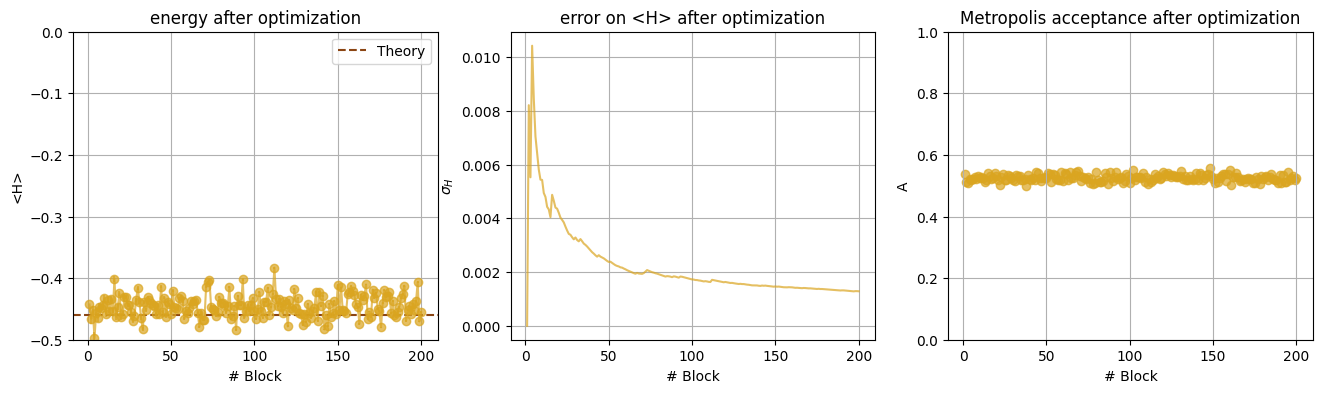

In [15]:
#energy after optimization
dataopt=np.loadtxt("OUTPUT/local_energy.dat")

N=dataopt[:,0]
Hopt=dataopt[:,1]
erropt=dataopt[:,3]

fig, ax = plt.subplots( 1, 3, figsize=(16,4))

ax[0].errorbar(N, Hopt, yerr=erropt,fmt='-o', color= 'GoldenRod', alpha=0.7)
ax[0].grid(True)
ax[0].set_xlabel("# Block")
ax[0].set_ylabel("<H>")
ax[0].set_title("energy after optimization")
ax[0].axhline(-0.46046587969271513, color='saddlebrown', label="Theory", ls='--')
ax[0].set_ylim(-0.5,0.0)
ax[0].legend()
ax[1].plot(N, erropt, color= 'GoldenRod', alpha=0.7)
ax[1].grid(True)
ax[1].set_xlabel("# Block")
ax[1].set_ylabel(r"$\sigma_H$")
ax[1].set_title("error on <H> after optimization")
acc=np.loadtxt("OUTPUT/acceptance.dat")
Na=acc[:,0]
acc=acc[:,1]
ax[2].scatter(Na, acc, color= 'GoldenRod', alpha=0.7)
ax[2].grid(True)
ax[2].set_xlabel("# Block")
ax[2].set_ylabel("A")
ax[2].set_ylim(0.0,1.0)
ax[2].set_title("Metropolis acceptance after optimization")

plt.show()

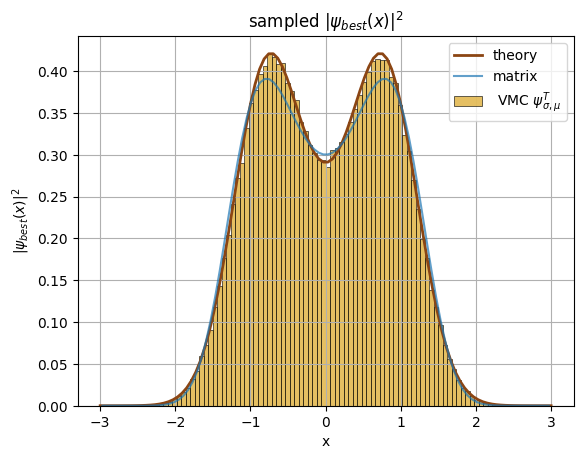

In [23]:
#pdf sampling histogram
def Vpot(x):
    return (x**2 - 2.5)*x**2
hbar = 1
m = 1
a = 6
N = 100
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0]  # passo
V = Vpot(x)
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)


def Psi2Real(x,mu,sigma):
    term1=np.exp(-((x-mu)**2)/(2*sigma**2))
    term2=np.exp(-((x+mu)**2)/(2*sigma**2))
    psi=term1+term2
    return psi**2
datapdf=np.loadtxt("OUTPUT/PDF.dat")
#bins=datapdf[:,0]
pdf=datapdf
nbins=len(pdf)
bin_size=(a)/nbins#xmax-xmin/nbins
pdf/=(np.sum(pdf)*bin_size) #normalize
xhist=np.linspace(-a/2+bin_size/2,a/2-bin_size/2,nbins)

sigmaBest=sigma_walk[-1]
muBest=mu_walk[-1]
plt.bar(xhist, pdf, width=bin_size, align='center', alpha=0.7, color='GoldenRod', edgecolor='black', linewidth=0.6, label=r' VMC $\psi^T_{\sigma,\mu}$')
y=Psi2Real(xhist,muBest,sigmaBest)
y /= np.trapezoid(y, xhist) #normalize theoretical distribution integrating with trapezoid method
plt.plot(x, y, color='saddlebrown', linewidth=2.0, label='theory')
plt.xlabel('x')
plt.ylabel(r'$|\psi_{best}(x)|^2$')
plt.title(r'sampled $|\psi_{best}(x)|^2$')
plt.grid(True)
plt.plot(xhist,(psi[0])**2, label='matrix', alpha=0.7)
plt.legend()
plt.show()


In [17]:
print("muBest =", muBest)
print("sigmaBest =", sigmaBest)


muBest = 0.790382
sigmaBest = 0.609947
